<a href="https://colab.research.google.com/github/jhp12204813-byte/AI-application-class/blob/week02/Week02_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Application — 2주차 시연 노트북
## Python 데이터 처리 기초: 차량 주행 로그 분석

**스마트모빌리티학과 | 시나리오: 합성(synthetic) 차량 주행 로그 24시간 분석**

흐름: **NumPy** (배열 생성·통계) → **Pandas** (DataFrame·필터링·groupby·결측치) → **matplotlib** (시각화)

- 외부 데이터 다운로드 없이, NumPy로 직접 데이터를 생성합니다.
- 셀은 **위에서부터 순서대로** 실행하세요 (`Shift + Enter`).

In [1]:
# 라이브러리 불러오기 (import)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 재현성(reproducibility)을 위한 난수 시드 고정
np.random.seed(42)

print("NumPy :", np.__version__)
print("Pandas:", pd.__version__)

NumPy : 2.1.3
Pandas: 2.2.3


## 1. NumPy — 합성 주행 로그 데이터 생성

24시간 동안 **1분 간격**으로 기록된 차량 주행 로그를 만듭니다 (총 1,440개 샘플).

| 변수 | 의미 | 생성 방법 |
|---|---|---|
| `minute` | 0시부터 경과한 분 | `np.arange` |
| `speed` | 속도 (km/h) | 시간대별 패턴 + 정규분포 잡음 (출퇴근 정체 반영) |
| `fuel_eff` | 연비 (km/L) | 속도의 함수 — 경제속도 65km/h 부근에서 최적 |

In [2]:
# 배열 생성: 24시간 x 60분 = 1440개 시각
minute = np.arange(0, 24 * 60)          # [0, 1, ..., 1439]
hour = minute // 60                      # 각 샘플의 '시(hour)'

# 시간대별 기본 속도: 심야는 빠르고, 출퇴근(8시/18시)은 정체로 느림
base_speed = 70 - 25 * np.exp(-((hour - 8) ** 2) / 4) - 28 * np.exp(-((hour - 18) ** 2) / 5)

# 잡음(noise) 추가 후 물리적 범위로 제한 — 벡터화 연산 + 브로드캐스팅
speed = base_speed + np.random.normal(0, 8, size=minute.size)
speed = np.clip(speed, 0, 130)

# 연비: 65km/h 부근에서 최적인 2차 곡선 + 잡음
fuel_eff = 16 - 0.0025 * (speed - 65) ** 2 + np.random.normal(0, 0.8, size=minute.size)
fuel_eff = np.clip(fuel_eff, 2, None)

print("shape:", speed.shape, "| dtype:", speed.dtype, "| ndim:", speed.ndim)
print("speed 앞 5개:", speed[:5].round(1))

shape: (1440,) | dtype: float64 | ndim: 1
speed 앞 5개: [74.  68.9 75.2 82.2 68.1]


## 2. NumPy — 슬라이싱, 통계 함수, 불리언 인덱싱

배열을 받으면 `shape`/`dtype` 확인 → 기초 통계 → 조건 추출 순서로 데이터의 '체온'을 잽니다.
불리언 인덱싱(Boolean Indexing)은 모빌리티 실무에서 **이벤트 검출**(과속, 급감속)에 그대로 쓰이는 패턴입니다.

In [3]:
# 슬라이싱: 오전 8시대(480~539분) vs 새벽 3시대 속도 비교
print("8시대 평균 속도 :", speed[480:540].mean().round(1), "km/h  (출근 정체)")
print("3시대 평균 속도 :", speed[180:240].mean().round(1), "km/h  (심야)")

# 기초 통계 함수
print("\n--- 24시간 전체 통계 ---")
print("평균    :", np.mean(speed).round(1))
print("중앙값  :", np.median(speed).round(1))
print("표준편차:", np.std(speed).round(1))
print("최소/최대:", np.min(speed).round(1), "/", np.max(speed).round(1))
print("95백분위:", np.percentile(speed, 95).round(1))

8시대 평균 속도 : 42.9 km/h  (출근 정체)
3시대 평균 속도 : 70.4 km/h  (심야)

--- 24시간 전체 통계 ---
평균    : 62.0
중앙값  : 63.7
표준편차: 12.3
최소/최대: 18.8 / 100.8
95백분위: 79.9


In [4]:
LIMIT = 80  # 제한속도 (km/h)

mask = speed > LIMIT                 # True/False 배열 (불리언 마스크)
print("마스크 앞 10개:", mask[:10])
print("과속 샘플 수   :", np.sum(mask), "개 /", speed.size)
print("과속 비율      :", (mask.mean() * 100).round(1), "%")
print("과속 시 평균속도:", speed[mask].mean().round(1), "km/h")

# 조건 결합: 심야(0~4시)이면서 과속 — 각 조건에 괄호 필수!
night_over = speed[(hour < 5) & (speed > LIMIT)]
print("심야 과속 샘플 :", night_over.size, "개")

# np.where: 벡터화된 if-else로 라벨 부여
status = np.where(speed > LIMIT, "OVER", "OK")
print("라벨 예시:", status[:8])

마스크 앞 10개: [False False False  True False False  True False False False]
과속 샘플 수   : 72 개 / 1440
과속 비율      : 5.0 %
과속 시 평균속도: 83.8 km/h
심야 과속 샘플 : 27 개
라벨 예시: ['OK' 'OK' 'OK' 'OVER' 'OK' 'OK' 'OVER' 'OK']


## 3. Pandas — DataFrame 만들기와 훑어보기

여러 배열을 **하나의 표(테이블)**로 묶으면 이후 필터링·집계가 훨씬 편해집니다.
도로 유형(road) 같은 **문자열 열**을 함께 담을 수 있는 것이 DataFrame의 강점.

새 데이터를 받으면 3단 콤보: `head()` → `info()` → `describe()`

In [5]:
# 도로 유형: 속도 기준 단순 분류 (고속도로/시내)
road = np.where(speed >= 70, "highway", "urban")

df = pd.DataFrame({
    "minute": minute,
    "hour": hour,
    "speed": speed.round(1),
    "fuel_eff": fuel_eff.round(2),
    "road": road,
})

print("shape:", df.shape)
df.head()

shape: (1440, 5)


,minute,hour,speed,fuel_eff,road
0,0,0,74.0,16.33,highway
1,1,0,68.9,16.90,urban
2,2,0,75.2,15.89,highway
3,3,0,82.2,14.22,highway
4,4,0,68.1,16.30,urban


In [ ]:
df.info()                    # 행 수, 열 타입, 결측치 여부 요약
print()
print(df["road"].value_counts())   # 범주형 열의 빈도
df.describe().round(2)       # 숫자 열의 기초 통계

## 4. Pandas — 필터링(Filtering)과 groupby 집계

- 필터링: NumPy 불리언 인덱싱과 **완전히 같은 원리**가 DataFrame에 적용됩니다.
- groupby: **Split → Apply → Combine**. 교통공학의 **시간대별 교통 특성 분석**이 바로 이 연산입니다.

In [6]:
# 열 선택
print(type(df["speed"]))              # Series
print(type(df[["speed", "road"]]))  # DataFrame (대괄호 2겹)

# 행 필터링
over = df[df["speed"] > 80]
print("\n과속 행 수:", len(over))

# 복합 조건: 시내(urban)인데 60km/h 초과
urban_fast = df[(df["road"] == "urban") & (df["speed"] > 60)]
print("시내 60 초과 행 수:", len(urban_fast))

# 새 열 추가: m/s 단위 속도 (벡터화 연산)
df["speed_ms"] = (df["speed"] * 1000 / 3600).round(2)
df.head(3)

<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>

과속 행 수: 72
시내 60 초과 행 수: 458


,minute,hour,speed,fuel_eff,road,speed_ms
0,0,0,74.0,16.33,highway,20.56
1,1,0,68.9,16.90,urban,19.14
2,2,0,75.2,15.89,highway,20.89


In [7]:
# 시간대별 평균 속도 (Series 반환)
hourly_speed = df.groupby("hour")["speed"].mean()
print(hourly_speed.round(1).head(6))

# 시간대 x 도로유형별 과속 비율(%) — 두 기준 groupby
df["is_over"] = df["speed"] > 80
over_rate = df.groupby(["road", "hour"])["is_over"].mean() * 100
print("\n도로유형·시간대별 과속 비율(%) 일부:")
print(over_rate.round(1).head(5))

# 도로유형별 요약: named aggregation (결과 열 이름 직접 지정)
road_summary = df.groupby("road").agg(
    mean_speed=("speed", "mean"),
    mean_fuel=("fuel_eff", "mean"),
    max_speed=("speed", "max"),
    n_samples=("speed", "count"),
).round(2)
road_summary

hour
0    68.8
1    70.0
2    70.7
3    70.4
4    69.4
5    67.7
Name: speed, dtype: float64

도로유형·시간대별 과속 비율(%) 일부:
road     hour
highway  0       15.4
         1       20.7
         2       22.9
         3        8.6
         4       20.7
Name: is_over, dtype: float64


,mean_speed,mean_fuel,max_speed,n_samples
road,,,,
highway,75.72,15.65,100.8,414
urban,56.47,15.61,70.0,1026


## 5. 전처리 — 결측치, 이상치, 정규화

실제 센서 로그에는 **터널 구간(통신 단절)**의 결측치(NaN)와 **GPS 튐**으로 인한 이상치(Outlier)가 섞여 있습니다.

여기서는 일부러 문제를 주입한 뒤 **탐지 → 원인 판단 → 처리 → 확인** 순서를 실습합니다.

1. 결측치: `isna` → `dropna` / `fillna` / `ffill` 비교 (시계열은 `ffill`이 자연스러움)
2. 이상치: IQR(사분위 범위) 방법으로 탐지 → 물리적으로 불가능한 값만 제거
3. 정규화: Min-Max로 0~1 범위 변환 — **이상치 제거 후에** 수행해야 왜곡이 없음

In [8]:
# 결측치 주입: 임의의 60개 시각에서 연비 센서 값 소실 (터널 구간 가정)
df_miss = df.copy()
nan_idx = np.random.choice(df_miss.index, size=60, replace=False)
df_miss.loc[nan_idx, "fuel_eff"] = np.nan

# 1) 탐지
print("열별 결측치 개수:")
print(df_miss.isna().sum())

# 2) 처리 전략 비교
drop_ver = df_miss.dropna(subset=["fuel_eff"])                      # 삭제
mean_ver = df_miss["fuel_eff"].fillna(df_miss["fuel_eff"].mean())  # 평균 대체
ffill_ver = df_miss["fuel_eff"].ffill()                             # 직전 값 대체
print("\ndropna 후 행 수:", len(drop_ver), "(원본", len(df_miss), ")")

# 시계열 센서 로그이므로 ffill 채택 → 3) 최종 확인
df_miss["fuel_eff"] = ffill_ver
print("최종 전체 결측치:", df_miss.isna().sum().sum())

열별 결측치 개수:
minute       0
hour         0
speed        0
fuel_eff    60
road         0
speed_ms     0
is_over      0
dtype: int64

dropna 후 행 수: 1380 (원본 1440 )
최종 전체 결측치: 0


In [9]:
# 이상치 주입: 5개 시각에 GPS 튐으로 속도 200~300 기록
df_out = df_miss.copy()
spike_idx = np.random.choice(df_out.index, size=5, replace=False)
df_out.loc[spike_idx, "speed"] = np.random.uniform(200, 300, 5).round(1)

# IQR 방법으로 탐지
q1, q3 = df_out["speed"].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = df_out[(df_out["speed"] < lower) | (df_out["speed"] > upper)]
print(f"정상 범위: {lower:.1f} ~ {upper:.1f} km/h")
print("탐지된 이상치:", sorted(outliers["speed"].tolist())[-5:])

# 물리적으로 불가능한 값 → 제거 후 Min-Max 정규화
df_clean = df_out[(df_out["speed"] >= lower) & (df_out["speed"] <= upper)].copy()
smin, smax = df_clean["speed"].min(), df_clean["speed"].max()
df_clean["speed_norm"] = (df_clean["speed"] - smin) / (smax - smin)
print("\n정규화 결과 범위:", df_clean["speed_norm"].min(), "~", df_clean["speed_norm"].max())

정상 범위: 27.9 ~ 97.2 km/h
탐지된 이상치: [216.4, 267.4, 269.2, 283.2, 299.2]

정규화 결과 범위: 0.0 ~ 1.0


## 6. matplotlib — 시각화 4종 세트

같은 데이터를 네 가지 관점으로 봅니다.

| 그래프 | 질문 |
|---|---|
| 선 그래프 (line) | 시간에 따라 속도가 어떻게 변하는가? (출퇴근 정체) |
| 막대 그래프 (bar) | 어느 시간대에 과속이 많은가? |
| 산점도 (scatter) | 속도와 연비의 관계는? (경제속도) |
| 히스토그램 (histogram) | 속도는 어떻게 분포하는가? |

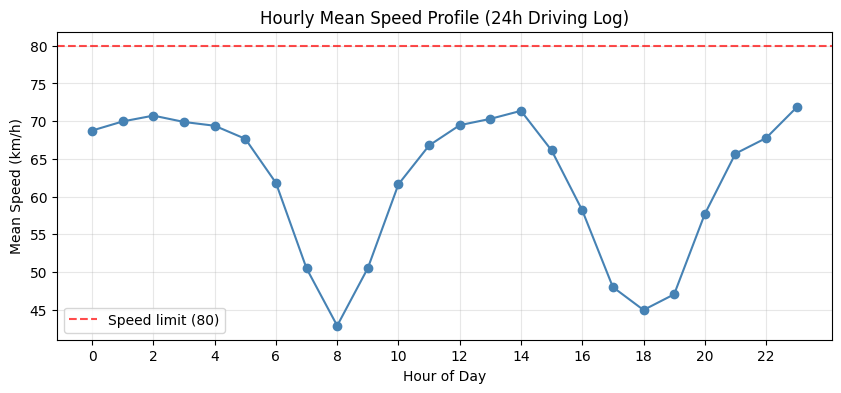

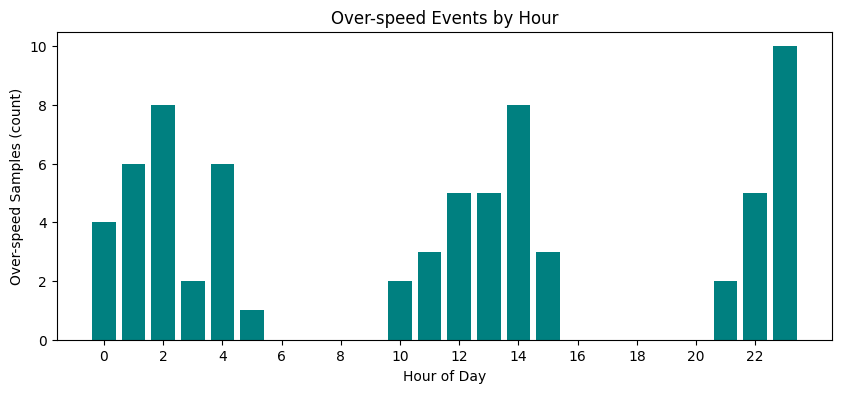

In [10]:
# 1) 선 그래프: 시간대별 평균 속도 프로파일
hourly = df_clean.groupby("hour")["speed"].mean()

plt.figure(figsize=(10, 4))
plt.plot(hourly.index, hourly.values, marker="o", color="steelblue")
plt.axhline(80, color="red", linestyle="--", alpha=0.7, label="Speed limit (80)")
plt.xlabel("Hour of Day")
plt.ylabel("Mean Speed (km/h)")
plt.title("Hourly Mean Speed Profile (24h Driving Log)")
plt.xticks(range(0, 24, 2))
plt.legend()
plt.grid(alpha=0.3)
plt.show()
# 8시/18시 부근이 움푹 꺼진 것 = 출퇴근 정체

# 2) 막대 그래프: 시간대별 과속 샘플 수
over_by_hour = df_clean[df_clean["speed"] > 80].groupby("hour").size()
over_by_hour = over_by_hour.reindex(range(24), fill_value=0)

plt.figure(figsize=(10, 4))
plt.bar(over_by_hour.index, over_by_hour.values, color="teal")
plt.xlabel("Hour of Day")
plt.ylabel("Over-speed Samples (count)")
plt.title("Over-speed Events by Hour")
plt.xticks(range(0, 24, 2))
plt.show()
# 정체 없는 심야~오전 시간대에 과속이 집중됨

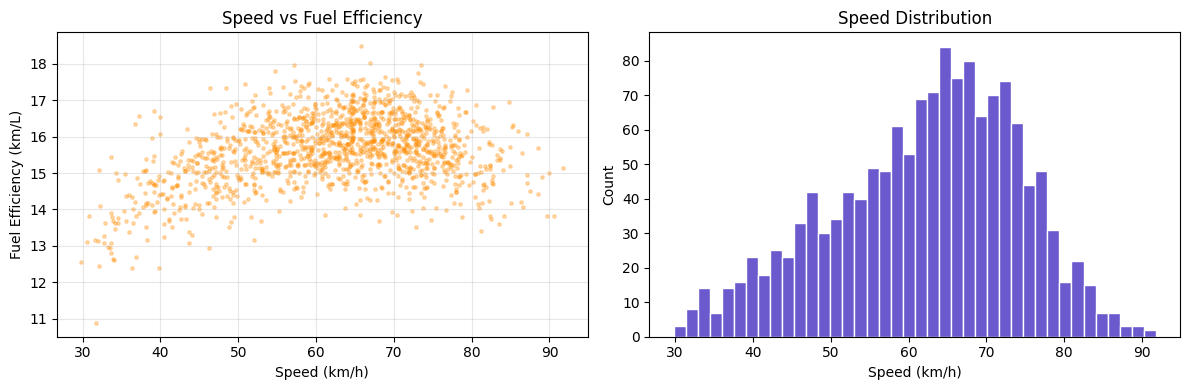

In [11]:
# 3) 산점도 + 4) 히스토그램: subplot으로 나란히
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df_clean["speed"], df_clean["fuel_eff"], s=6, alpha=0.3, color="darkorange")
axes[0].set_xlabel("Speed (km/h)")
axes[0].set_ylabel("Fuel Efficiency (km/L)")
axes[0].set_title("Speed vs Fuel Efficiency")
axes[0].grid(alpha=0.3)

axes[1].hist(df_clean["speed"], bins=40, color="slateblue", edgecolor="white")
axes[1].set_xlabel("Speed (km/h)")
axes[1].set_ylabel("Count")
axes[1].set_title("Speed Distribution")

plt.tight_layout()
plt.show()
# 산점도: 65km/h 부근에서 연비 최적(경제속도) 곡선이 보임

## 7. 정리

| 단계 | 도구 | 오늘 한 일 |
|---|---|---|
| 데이터 생성 | NumPy | `arange`, `random`, `clip`, 브로드캐스팅, 벡터화 |
| 이벤트 분석 | NumPy | 불리언 인덱싱으로 과속 검출, `np.where` |
| 표 변환·집계 | Pandas | DataFrame, 필터링, `groupby` 시간대별 집계 |
| 결측치 | Pandas | `isna` → `dropna`/`fillna`/`ffill` 비교 |
| 이상치·정규화 | NumPy+Pandas | IQR 탐지, Min-Max 정규화 |
| 시각화 | matplotlib | 선/막대/산점도/히스토그램 |

**다음 주(3주차)**: 이렇게 전처리한 데이터를 머신러닝 모델(회귀, Regression)에 넣는 방법을 배웁니다.

**과제 1**: `과제1_데이터처리.ipynb` — 오늘과 같은 주행 로그로 빈칸 채우기 7문제 (기본 5 + 심화 2, 화요일 23:59까지 GitHub push + e-Campus 제출 후 이메일 알림).